# F · CS / W 분해 모델

**동기**: CSW는 성격이 다른 두 사건의 합이다.
```
P(CSW) = P(swing)·P(whiff | swing)  +  P(take)·P(called strike | take)
```
- **콜드스트라이크**: 타자의 '지켜봄' 판단 + 심판 + 존 공략 성향이 좌우
- **헛스윙**: 구위·구종 배합·타자 컨택 능력이 좌우

하나의 타깃으로 합치면 두 메커니즘이 섞여 학습이 흐려진다. **세 모델을 따로 학습해 결합**한다.
(모든 모델은 동일한 **엄격 투구 전** 피처만 사용 — 현재 투구 정보 없음)

**추가 효과**: 성능 변화가 *콜스트라이크 쪽*인지 *헛스윙 쪽*인지 설명할 수 있다.

In [1]:
import json, sys, warnings; warnings.filterwarnings("ignore")
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt
sys.path.insert(0, "src"); import csw_pipeline as P
import plotstyle; plotstyle.apply()   # 한글 폰트
V3 = Path("out/v3")
meta = json.load(open("cache/meta.json")); df = pd.read_parquet("cache/features.parquet")
tr = df["game_year"].isin(P.TRAIN_YEARS).to_numpy(); te = df["game_year"].eq(2019).to_numpy()
BASE = {"league_mean": 0.5957, "count_only": 0.5790}
print(f"train {int(tr.sum()):,} / test {int(te.sum()):,} | 피처 basic {len(meta['basic_feats'])} "
      f"/ derived {len(meta['derived_feats'])} / +PitchPredict {len(meta['pp_feats'])} = full {len(meta['full_feats'])}")

train 238,054 / test 94,150 | 피처 basic 36 / derived 205 / +PitchPredict 52 = full 257


## 1. 세 모델의 개별 성능
각 모델은 자기 대상 투구에서만 평가한다 (B=스윙한 공, C=지켜본 공).

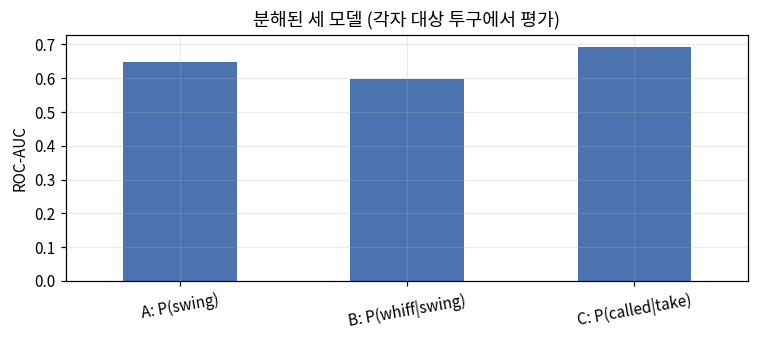

,n,base,logloss,roc_auc,pr_auc
A: P(swing),94150.0,0.4774,0.6586,0.6492,0.6066
B: P(whiff|swing),44951.0,0.2441,0.5489,0.5976,0.3148
C: P(called|take),49199.0,0.3183,0.5750,0.6939,0.4779


In [2]:
F = json.load(open(V3/"F_decomp.json"))
sub = pd.DataFrame({k: F[k] for k in ["A_swing","B_whiff_given_swing","C_called_given_take"]}).T
sub.index = ["A: P(swing)", "B: P(whiff|swing)", "C: P(called|take)"]
ax = sub["roc_auc"].plot.bar(figsize=(7,3.2), color="#4C72B0"); ax.set_ylabel("ROC-AUC")
ax.set_title("분해된 세 모델 (각자 대상 투구에서 평가)"); plt.xticks(rotation=10); plt.tight_layout(); plt.show()
sub[["n","base","logloss","roc_auc","pr_auc"]]

**관찰**: 세 사건의 예측 난이도가 서로 다르다. 특히 `P(swing)`은 카운트 의존이 커서 상대적으로 잘 맞고, 나머지는 어렵다.

## 2. 결합 결과 — 분해가 단일 모델을 이긴다

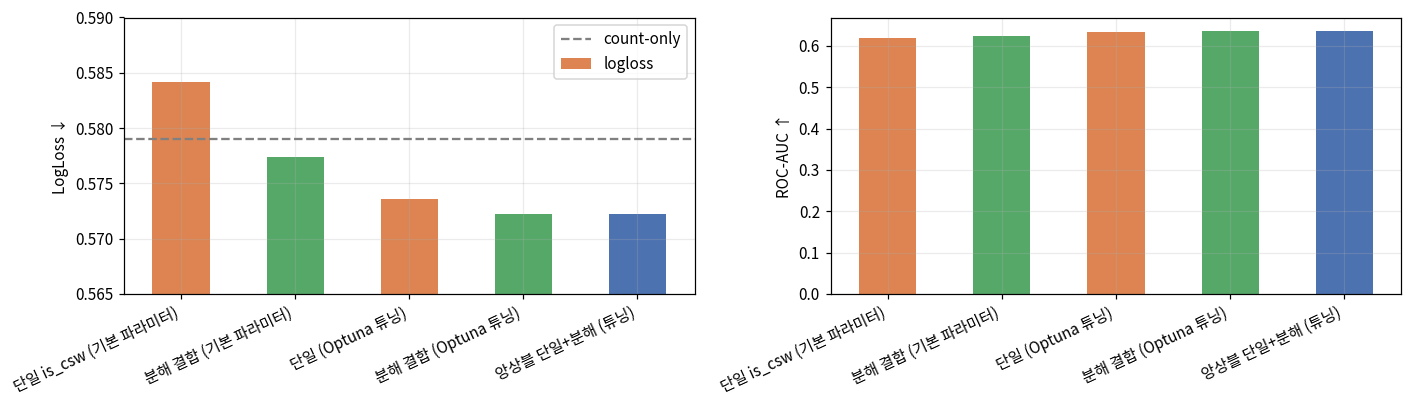

,logloss,roc_auc,pr_auc,ece
단일 is_csw (기본 파라미터),0.5842,0.6198,0.3761,0.0373
분해 결합 (기본 파라미터),0.5774,0.6252,0.3857,0.0165
단일 (Optuna 튜닝),0.5736,0.6334,0.3915,0.0057
분해 결합 (Optuna 튜닝),0.5722,0.6368,0.3971,0.0061
앙상블 단일+분해 (튜닝),0.5722,0.6369,0.3966,0.0059


In [3]:
FF = json.load(open(V3/"F_final.json"))
rows = {"단일 is_csw (기본 파라미터)": F["single_is_csw"],
        "분해 결합 (기본 파라미터)": F["combined_decomposed"],
        "단일 (Optuna 튜닝)": FF["tuned_single"],
        "분해 결합 (Optuna 튜닝)": FF["tuned_decomposed"],
        "앙상블 단일+분해 (튜닝)": FF["tuned_ensemble"]}
t = pd.DataFrame(rows).T[["logloss","roc_auc","pr_auc","ece"]]
fig, ax = plt.subplots(1,2, figsize=(13,3.8))
t["logloss"].plot.bar(ax=ax[0], color=["#DD8452","#55A868","#DD8452","#55A868","#4C72B0"])
ax[0].axhline(BASE["count_only"], ls="--", c="gray", label="count-only"); ax[0].set_ylim(0.565,0.59)
ax[0].set_ylabel("LogLoss ↓"); ax[0].legend(); plt.setp(ax[0].get_xticklabels(), rotation=25, ha="right")
t["roc_auc"].plot.bar(ax=ax[1], color=["#DD8452","#55A868","#DD8452","#55A868","#4C72B0"])
ax[1].set_ylabel("ROC-AUC ↑"); plt.setp(ax[1].get_xticklabels(), rotation=25, ha="right")
plt.tight_layout(); plt.show()
t

## 3. 결론
- **분해가 단일보다 일관되게 낫다** (기본 파라미터에서도, 튜닝 후에도).
- 최종 최고: **분해 결합 + Optuna** → 아래 셀 수치.
- 여전히 count-only 대비 개선폭은 제한적 — **D의 천장 진단**(위치를 모르면 AUC 0.63 부근)과 일치한다.

In [4]:
best = FF["tuned_decomposed"]
print(f"최종 최고 모델: 분해 결합 + Optuna")
print(f"  TEST LogLoss {best['logloss']:.4f}  (count-only {BASE['count_only']:.4f} 대비 {best['logloss']-BASE['count_only']:+.4f})")
print(f"  ROC-AUC {best['roc_auc']:.4f} | PR-AUC {best['pr_auc']:.4f} | ECE {best['ece']:.4f}")
print(f"  리그평균({BASE['league_mean']:.4f}) 대비 {best['logloss']-BASE['league_mean']:+.4f}")

최종 최고 모델: 분해 결합 + Optuna
  TEST LogLoss 0.5722  (count-only 0.5790 대비 -0.0068)
  ROC-AUC 0.6368 | PR-AUC 0.3971 | ECE 0.0061
  리그평균(0.5957) 대비 -0.0235
